In [47]:
# Import required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [48]:
# Load MNIST dataset using Keras
# This is an easier and faster method

from tensorflow.keras.datasets import mnist

print("Loading MNIST dataset...")

(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Dataset loaded successfully!")
print("Training images:", X_train.shape)
print("Testing images:", X_test.shape)


Loading MNIST dataset...
Dataset loaded successfully!
Training images: (60000, 28, 28)
Testing images: (10000, 28, 28)


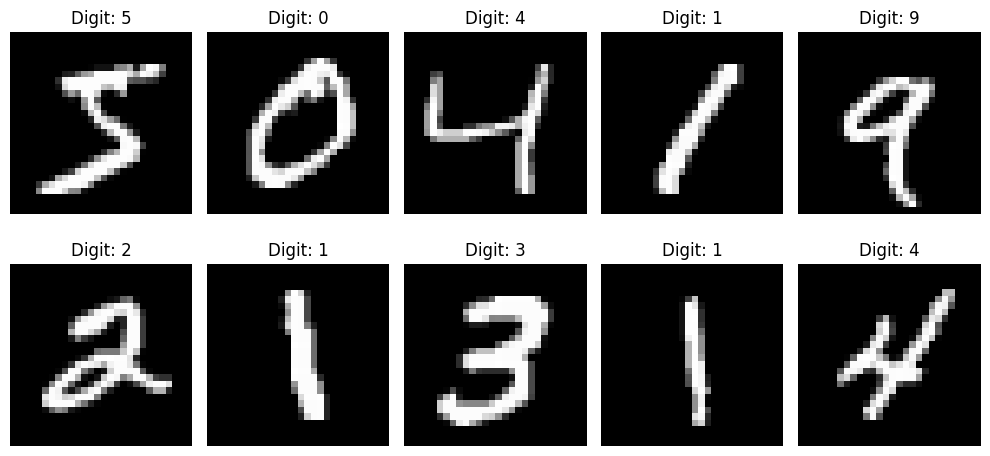

In [49]:
# Visualize sample images

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(f"Digit: {y_train[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [50]:
# Preprocess the image data

# Convert pixel values from 0-255 to 0-1
X_train = X_train / 255.0
X_test = X_test / 255.0

# Convert each 28x28 image into a single row of 784 pixels
X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (60000, 784)
Testing data shape: (10000, 784)


In [51]:
# Train Logistic Regression model

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

print("Training Logistic Regression model...")

logistic_model = LogisticRegression(
    max_iter=100,
    solver='lbfgs'
)

logistic_model.fit(X_train, y_train)

# Make predictions
logistic_predictions = logistic_model.predict(X_test)

# Calculate accuracy
logistic_accuracy = accuracy_score(
    y_test,
    logistic_predictions
)

print("Logistic Regression Accuracy:", logistic_accuracy)

Training Logistic Regression model...
Logistic Regression Accuracy: 0.9257


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [52]:
# Train Random Forest model

from sklearn.ensemble import RandomForestClassifier

print("Training Random Forest model...")

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

# Make predictions
rf_predictions = rf_model.predict(X_test)

# Calculate accuracy
rf_accuracy = accuracy_score(
    y_test,
    rf_predictions
)

print("Random Forest Accuracy:", rf_accuracy)


Training Random Forest model...
Random Forest Accuracy: 0.9704


In [53]:
# Compare model performance

import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        logistic_accuracy,
        rf_accuracy
    ]
})

print(results)

                 Model  Accuracy
0  Logistic Regression    0.9257
1        Random Forest    0.9704


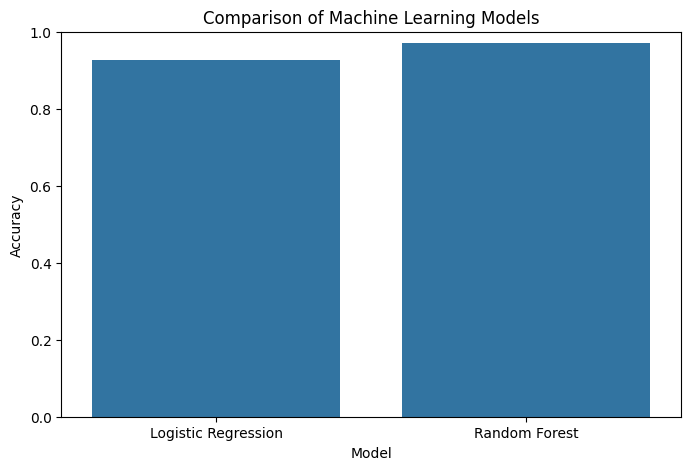

In [54]:
# Visualize model comparison

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

sns.barplot(
    data=results,
    x="Model",
    y="Accuracy"
)

plt.title("Comparison of Machine Learning Models")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

plt.show()


In [55]:
# Evaluate the best model

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# We select Random Forest as our best model
best_model = rf_model
best_predictions = rf_predictions

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, best_predictions)

precision = precision_score(
    y_test,
    best_predictions,
    average='weighted'
)

recall = recall_score(
    y_test,
    best_predictions,
    average='weighted'
)

f1 = f1_score(
    y_test,
    best_predictions,
    average='weighted'
)

print("Model: Random Forest")
print("-----------------------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Model: Random Forest
-----------------------------
Accuracy : 0.9704
Precision: 0.9703956228285179
Recall   : 0.9704
F1 Score : 0.9703722598097009


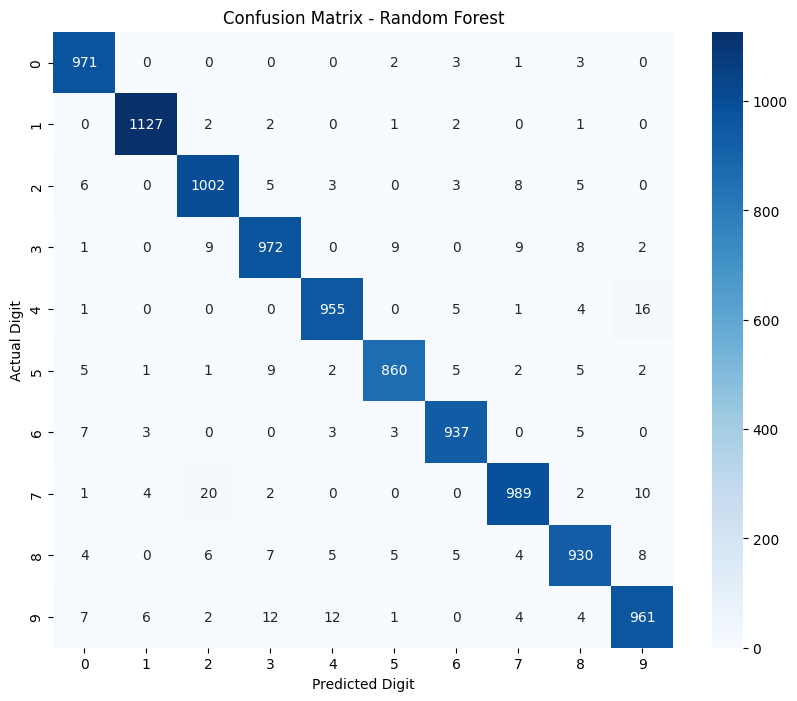

In [56]:
# Create Confusion Matrix

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(
    y_test,
    best_predictions
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted Digit")
plt.ylabel("Actual Digit")

plt.show()

In [57]:
# Classification Report

from sklearn.metrics import classification_report

print("Classification Report")
print("-----------------------------")

print(
    classification_report(
        y_test,
        best_predictions
    )
)

Classification Report
-----------------------------
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.96      0.97      0.97      1032
           3       0.96      0.96      0.96      1010
           4       0.97      0.97      0.97       982
           5       0.98      0.96      0.97       892
           6       0.98      0.98      0.98       958
           7       0.97      0.96      0.97      1028
           8       0.96      0.95      0.96       974
           9       0.96      0.95      0.96      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



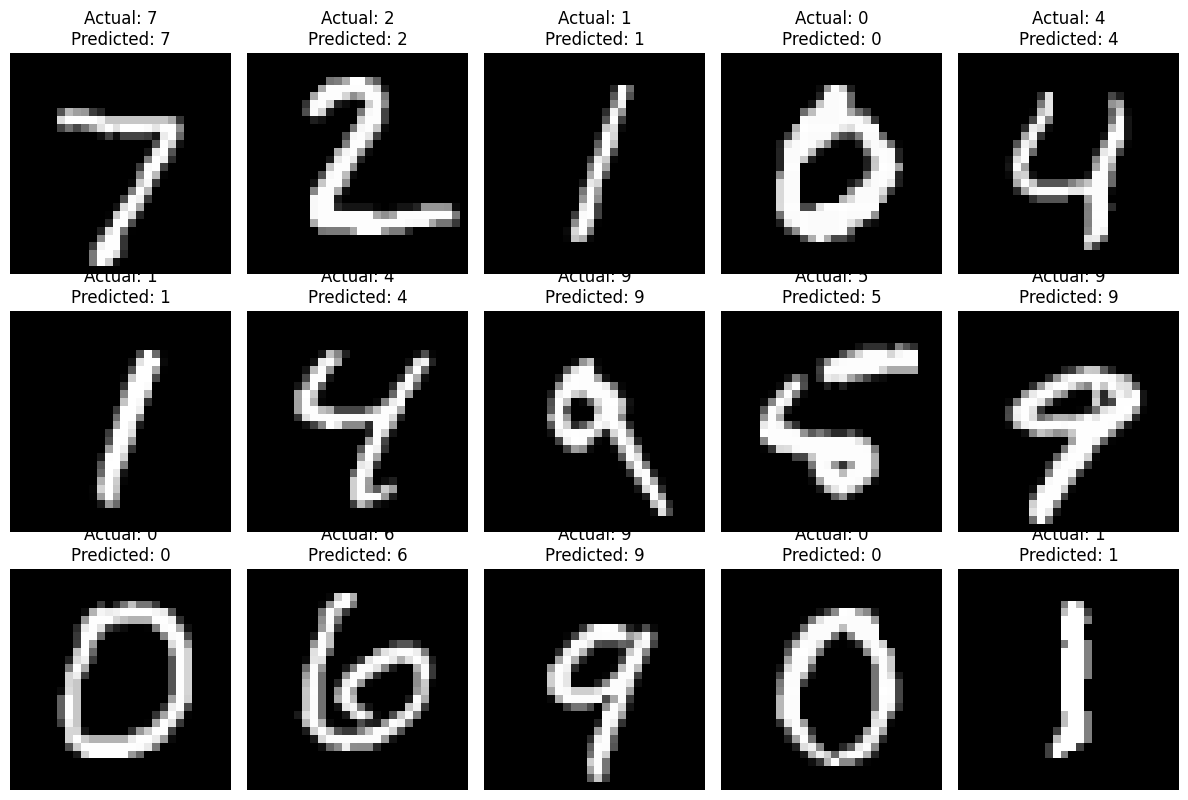

In [58]:
# Display predictions

plt.figure(figsize=(12, 8))

for i in range(15):

    prediction = best_model.predict(
        X_test[i].reshape(1, -1)
    )[0]

    plt.subplot(3, 5, i + 1)

    plt.imshow(
        X_test[i].reshape(28, 28),
        cmap='gray'
    )

    plt.title(
        f"Actual: {y_test[i]}\n"
        f"Predicted: {prediction}"
    )

    plt.axis('off')

plt.tight_layout()
plt.show()

In [60]:
# Final Model Results Table

final_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        logistic_accuracy,
        rf_accuracy
    ]
})

# Convert accuracy to percentage
final_results["Accuracy (%)"] = (
    final_results["Accuracy"] * 100
).round(2)

print("FINAL MODEL PERFORMANCE")
print("=======================")

print(final_results)

FINAL MODEL PERFORMANCE
                 Model  Accuracy  Accuracy (%)
0  Logistic Regression    0.9257         92.57
1        Random Forest    0.9704         97.04


In [61]:
# Save final results

final_results.to_csv(
    "model_results.csv",
    index=False
)

print("Results saved successfully!")

Results saved successfully!


In [62]:
# Final Project Summary

print("==========================================")
print("   IMAGE CLASSIFICATION PROJECT SUMMARY")
print("==========================================")

print("Dataset: MNIST Handwritten Digits")
print("Training Images: 60,000")
print("Testing Images: 10,000")
print("Models Used: Logistic Regression, Random Forest")
print("Best Model: Random Forest")
print("Best Model Accuracy:", round(rf_accuracy * 100, 2), "%")

print("==========================================")
print("Project completed successfully!")
print("==========================================")

   IMAGE CLASSIFICATION PROJECT SUMMARY
Dataset: MNIST Handwritten Digits
Training Images: 60,000
Testing Images: 10,000
Models Used: Logistic Regression, Random Forest
Best Model: Random Forest
Best Model Accuracy: 97.04 %
Project completed successfully!


# IMAGE CLASSIFICATION USING SUPERVISED MACHINE LEARNING

## 1. Introduction

Image classification is an important application of Machine Learning and Computer Vision. It is the process of assigning a predefined class or label to an image based on the patterns and features present in it.

This project focuses on developing an image classification system using supervised machine learning techniques. The MNIST Handwritten Digit Dataset is used for this project. The dataset contains images of handwritten digits from 0 to 9.

In this project, machine learning algorithms are trained using labeled images. The trained models learn the patterns of handwritten digits and predict the correct digit for previously unseen images.

Two supervised machine learning algorithms, Logistic Regression and Random Forest, are implemented and compared. The models are evaluated using accuracy, precision, recall, F1-score, classification report, and confusion matrix.

The Random Forest model achieved the best performance with an accuracy of 97.04% on the test dataset.

## 2. Problem Statement

The objective of this project is to develop a machine learning model that can automatically classify handwritten digit images into one of ten classes, ranging from 0 to 9.

## 3. Objectives

The main objectives of this project are:

1. To understand the application of supervised machine learning in image classification.
2. To use the MNIST handwritten digit dataset.
3. To preprocess image data for machine learning.
4. To train Logistic Regression and Random Forest models.
5. To compare the performance of different machine learning algorithms.
6. To evaluate the models using standard performance metrics.
7. To identify the best-performing model for handwritten digit classification.

## 4. Tools and Technologies Used

The following tools and technologies were used:

- Python
- Google Colab
- NumPy
- Pandas
- Matplotlib
- Seaborn
- Scikit-learn

## 5. Dataset Description

The MNIST dataset consists of handwritten digit images representing digits from 0 to 9.

The dataset used in this project contains:

- Training images: 60,000
- Testing images: 10,000
- Image size: 28 × 28 pixels
- Number of classes: 10
- Classes: 0, 1, 2, 3, 4, 5, 6, 7, 8, 9

Each image contains pixel values representing a handwritten digit.

## 6. Methodology

The following steps were followed to develop the image classification system:

1. Import the required Python libraries.
2. Load the MNIST handwritten digit dataset.
3. Explore and visualize sample images.
4. Normalize pixel values from the range 0–255 to 0–1.
5. Convert the 28 × 28 image into a one-dimensional array of 784 features.
6. Train the Logistic Regression model.
7. Train the Random Forest model.
8. Generate predictions using the trained models.
9. Compare the accuracy of both models.
10. Select the best-performing model.
11. Evaluate the selected model using accuracy, precision, recall, F1-score, and confusion matrix.
12. Display actual and predicted digit images.

## 7. Machine Learning Algorithms

### 7.1 Logistic Regression

Logistic Regression is a supervised machine learning classification algorithm. It learns the relationship between input features and class labels and is used to predict the class of new data.

In this project, Logistic Regression is used to classify handwritten digit images.

### 7.2 Random Forest

Random Forest is an ensemble machine learning algorithm that combines multiple decision trees to make predictions. Each tree provides a prediction, and the final prediction is determined using the combined results of the trees.

In this project, Random Forest was used for handwritten digit classification and achieved the highest accuracy among the implemented models.

## 8. Data Preprocessing

The MNIST images originally contain pixel values between 0 and 255. These values were normalized by dividing them by 255 so that the pixel values fall between 0 and 1.

The 28 × 28 pixel images were then converted into one-dimensional arrays containing 784 features. This transformation makes the image data suitable for traditional machine learning algorithms.

## 9. Model Evaluation

The models were evaluated using the following performance metrics:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix

The Random Forest model was selected as the best-performing model based on the comparison of model accuracy.

## 10. Results

The Random Forest model achieved an accuracy of 97.04% on the test dataset.

The model comparison showed that Random Forest performed better than Logistic Regression for the given MNIST image classification task.

The confusion matrix was also used to analyze the number of correctly and incorrectly classified images for each digit class.

## 11. Problem-Solving Approach

During the development of the project, several challenges were considered, including handling image data, converting images into machine learning features, and ensuring that the pixel values were appropriately scaled.

The images were normalized to improve the learning process, and the two-dimensional image data was converted into a one-dimensional feature representation.

Different machine learning algorithms were also compared to identify the model that provided better classification performance.

## 12. Conclusion

This project successfully demonstrated the application of supervised machine learning for handwritten digit image classification using the MNIST dataset.

Logistic Regression and Random Forest algorithms were implemented and evaluated. After comparing their performance, Random Forest was selected as the best-performing model, achieving an accuracy of 97.04%.

The project provided practical knowledge about data preprocessing, machine learning model training, model comparison, and performance evaluation.

## 13. Future Scope

The project can be improved in the future by using advanced deep learning techniques such as Convolutional Neural Networks (CNNs). CNNs are specifically designed for image classification and can learn important visual features automatically.

The system can also be extended to recognize more complex handwritten characters, alphabets, or real-world objects.

## 14. References

1. Scikit-learn Documentation
2. MNIST Handwritten Digit Dataset
3. Python Documentation
4. NumPy Documentation
5. Pandas Documentation
6. Matplotlib Documentation
7. Seaborn Documentation

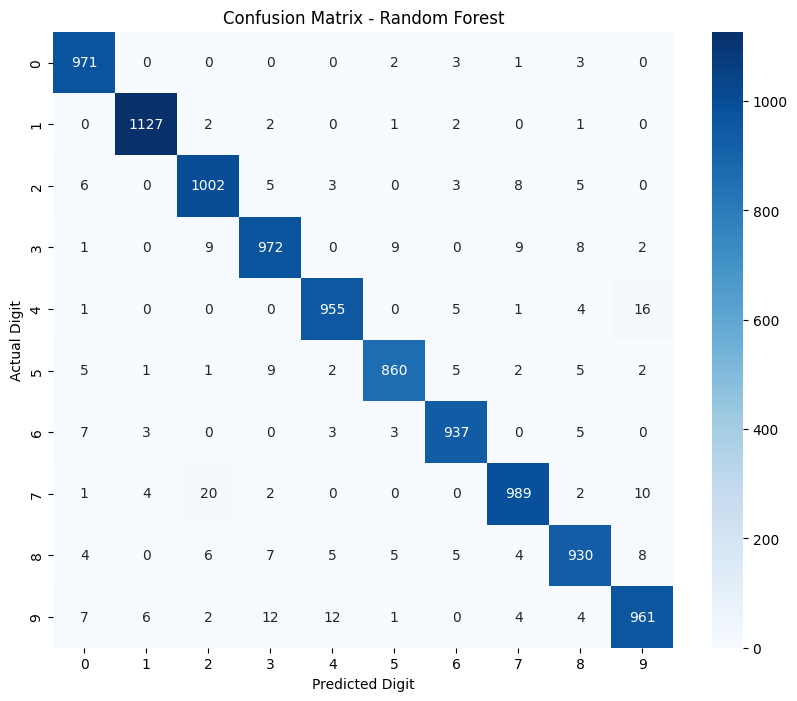

In [63]:
# STEP 15: Display Confusion Matrix

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, best_predictions)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted Digit")
plt.ylabel("Actual Digit")

plt.show()

In [64]:
# STEP 16: Classification Report

from sklearn.metrics import classification_report

print("Classification Report")
print("=====================")

print(
    classification_report(
        y_test,
        best_predictions
    )
)


Classification Report
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.96      0.97      0.97      1032
           3       0.96      0.96      0.96      1010
           4       0.97      0.97      0.97       982
           5       0.98      0.96      0.97       892
           6       0.98      0.98      0.98       958
           7       0.97      0.96      0.97      1028
           8       0.96      0.95      0.96       974
           9       0.96      0.95      0.96      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000

